# Machine learning data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import circmean, mode
import matplotlib.dates as mdates

import warnings
warnings.filterwarnings('ignore')
StartDate='1990-01-01'
EndDate= '2023-12-31'

## 1. Atmosphere

### 1.1 Daily resampling

In [2]:
# Create 'output' folder if it doesn't exist
if not os.path.exists('input'):
    os.makedirs('input')

# Load the cleaned data
file_path = '../atmosphere/output/wind_data_cleaned.csv'
data = pd.read_csv(file_path, parse_dates=['Timestamp'], index_col='Timestamp')

# Drop NaNs to avoid invalid math operations
data = data.dropna(subset=['WDIR', 'WSPD'])

# Convert wind direction to radians
wind_direction_radians = np.radians(data['WDIR'])

# Compute weighted sine and cosine components
sin_component = np.sin(wind_direction_radians) * data['WSPD']
cos_component = np.cos(wind_direction_radians) * data['WSPD']

# Resample and compute the weighted mean of sine and cosine components
mean_sin = sin_component.resample('D').sum()
mean_cos = cos_component.resample('D').sum()

# Compute resultant vector length (magnitude) for normalization
total_wind_speed = data['WSPD'].resample('D').sum()

# Normalize vector length by total wind speed
mean_sin /= total_wind_speed
mean_cos /= total_wind_speed

# Use atan2 to calculate the directional mean (in degrees)
mean_direction = np.degrees(np.arctan2(mean_sin, mean_cos))
mean_direction = (mean_direction + 360) % 360  # Ensure values between 0–360

# Compute median manually using circular statistics
def circular_median(angles):
    if len(angles) == 0:
        return np.nan
    angles = np.radians(angles)
    sin_sum = np.sum(np.sin(angles))
    cos_sum = np.sum(np.cos(angles))
    median = np.arctan2(sin_sum, cos_sum)
    median = np.degrees(median) % 360
    return median

median_direction = data['WDIR'].resample('D').apply(circular_median)

# Compute mode using circular mode
mode_direction = data['WDIR'].resample('D').apply(
    lambda x: np.atleast_1d(mode(x, nan_policy='omit').mode)[0] if np.size(mode(x, nan_policy='omit').mode) > 0 else np.nan
)

# Resample other parameters using max
resampled_data = pd.DataFrame({
    'WDIR_mean': mean_direction,
    'WDIR_median': median_direction,
    'WDIR_mode': mode_direction,
    'WSPD': data['WSPD'].resample('D').max(),
    'ATMP': data['ATMP'].resample('D').max(),
    'WTMP': data['WTMP'].resample('D').max(),
})

# Rename the index column
resampled_data = resampled_data.rename_axis('time')

# Save to CSV
output_file = 'input/wind_daily.csv'
resampled_data.to_csv(output_file)

print(f"\nResampled data saved to '{output_file}'")
#display(resampled_data)


Resampled data saved to 'input/wind_daily.csv'


### 1.2 Weekly resampling

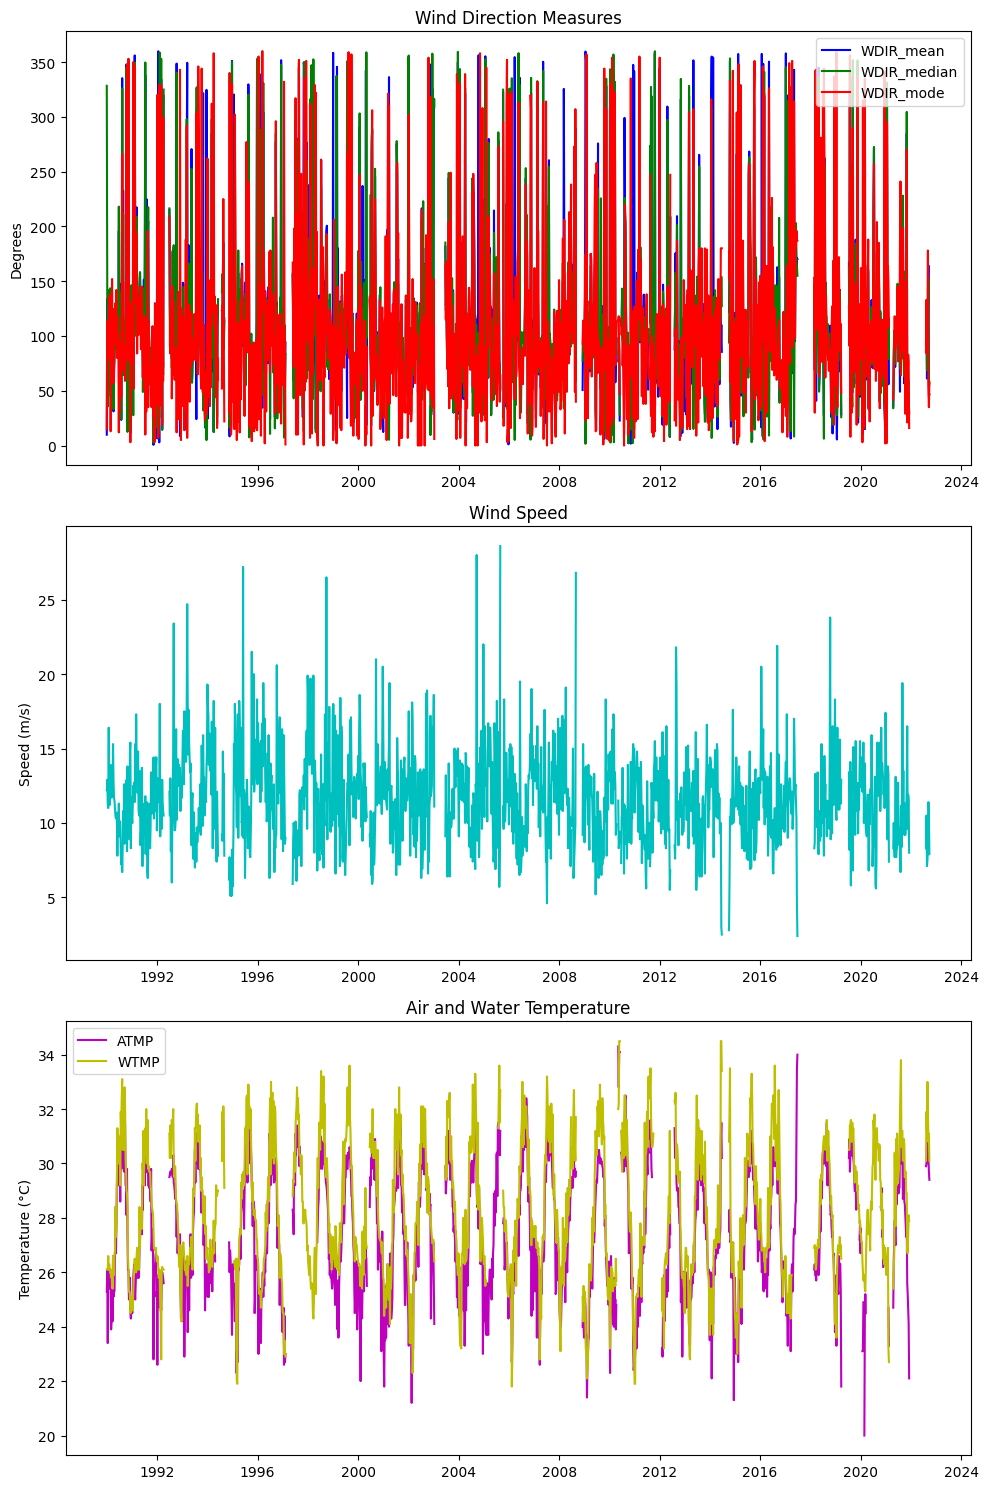


Resampled weekly data saved to 'input/wind_weekly.csv'


,WDIR_mean,WDIR_median,WDIR_mode,WSPD,ATMP,WTMP
time,,,,,,
1990-01-01,9.895843,328.282768,15.0,12.2,25.3,26.1
1990-01-08,133.922631,137.632056,113.0,12.9,26.1,26.1
1990-01-15,44.485475,35.621339,95.0,11.3,23.4,26.1
1990-01-22,113.017005,113.548079,105.0,11.0,26.1,26.6
1990-01-29,98.798579,109.931826,117.0,16.4,25.6,26.1
...,...,...,...,...,...,...
2023-11-27,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-04,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-11,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Create 'output' folder if it doesn't exist
if not os.path.exists('input'):
    os.makedirs('input')

# Load the cleaned data
file_path = '../atmosphere/output/wind_data_cleaned.csv'
data = pd.read_csv(file_path, parse_dates=['Timestamp'], index_col='Timestamp')

# Drop NaNs to avoid invalid math operations
data = data.dropna(subset=['WDIR', 'WSPD'])

# Define weekly date range
weekly_date_range = pd.date_range(start=StartDate, end=EndDate, freq='W-MON')

# Initialize DataFrame with this weekly index
weekly_wind = pd.DataFrame(index=weekly_date_range)
weekly_wind.index.name = 'Timestamp'

# Convert wind direction to radians
wind_direction_radians = np.radians(data['WDIR'])

# Compute weighted sine and cosine components
sin_component = np.sin(wind_direction_radians) * data['WSPD']
cos_component = np.cos(wind_direction_radians) * data['WSPD']

# Resample to weekly
mean_sin_weekly = sin_component.resample('W-MON').sum()
mean_cos_weekly = cos_component.resample('W-MON').sum()

# Normalize the resultant vector lengths
total_wind_speed_weekly = data['WSPD'].resample('W-MON').sum()
mean_sin_weekly /= total_wind_speed_weekly
mean_cos_weekly /= total_wind_speed_weekly

# Calculate directional mean (in degrees)
mean_direction_weekly = np.degrees(np.arctan2(mean_sin_weekly, mean_cos_weekly))
mean_direction_weekly = (mean_direction_weekly + 360) % 360

# Compute median using circular statistics
def circular_median(angles):
    if len(angles) == 0:
        return np.nan
    angles = np.radians(angles)
    sin_sum = np.sum(np.sin(angles))
    cos_sum = np.sum(np.cos(angles))
    median = np.arctan2(sin_sum, cos_sum)
    median = np.degrees(median) % 360
    return median

median_direction_weekly = data['WDIR'].resample('W-MON').apply(circular_median)

# Compute circular mode of wind direction
mode_direction_weekly = data['WDIR'].resample('W-MON').apply(
    lambda x: np.atleast_1d(mode(x, nan_policy='omit').mode)[0] if np.size(mode(x, nan_policy='omit').mode) > 0 else np.nan
)

# Compile resampled data
weekly_wind['WDIR_mean'] = mean_direction_weekly
weekly_wind['WDIR_median'] = median_direction_weekly
weekly_wind['WDIR_mode'] = mode_direction_weekly
weekly_wind['WSPD'] = data['WSPD'].resample('W-MON').max()
weekly_wind['ATMP'] = data['ATMP'].resample('W-MON').max()
weekly_wind['WTMP'] = data['WTMP'].resample('W-MON').max()

# Rename the index column
weekly_wind = weekly_wind.rename_axis('time')



# Create a 3x1 grid of subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# Plot WDIR_mean, WDIR_median, WDIR_mode on the first subplot
axs[0].plot(weekly_wind.index, weekly_wind['WDIR_mean'], label='WDIR_mean', color='b')
axs[0].plot(weekly_wind.index, weekly_wind['WDIR_median'], label='WDIR_median', color='g')
axs[0].plot(weekly_wind.index, weekly_wind['WDIR_mode'], label='WDIR_mode', color='r')
axs[0].set_title('Wind Direction Measures')
axs[0].set_ylabel('Degrees')
axs[0].legend(loc='best')

# Plot WSPD on the second subplot
axs[1].plot(weekly_wind.index, weekly_wind['WSPD'], color='c')
axs[1].set_title('Wind Speed')
axs[1].set_ylabel('Speed (m/s)')

# Plot ATMP and WTMP on the third subplot
axs[2].plot(weekly_wind.index, weekly_wind['ATMP'], label='ATMP', color='m')
axs[2].plot(weekly_wind.index, weekly_wind['WTMP'], label='WTMP', color='y')
axs[2].set_title('Air and Water Temperature')
axs[2].set_ylabel('Temperature (°C)')
axs[2].legend(loc='best')

# Adjust layout for better fit
plt.tight_layout()

# Show the plots
plt.show()

# Save to CSV
output_file_weekly = 'input/wind_weekly.csv'
weekly_wind.to_csv(output_file_weekly)

print(f"\nResampled weekly data saved to '{output_file_weekly}'")
display(weekly_wind)

## 2. Ocean

### 2.1 HAB 

#### 2.1.1 Daily resampling max

In [4]:
import pandas as pd

# Reading the CSV file
file_path = "../ocean/output/hab_charlotte_harbor_all.csv"
df = pd.read_csv(file_path)

# Converting SAMPLE_DATE to datetime, set as index, rename index
df['SAMPLE_DATE'] = pd.to_datetime(df['SAMPLE_DATE'])
df.set_index('SAMPLE_DATE', inplace=True)

# Create the 'num_samples' column
df['samples'] = df.groupby(df.index).size()

# Create the 'num_high_samples' column using the selection for high CELLCOUNT
high_count_criteria = df['CELLCOUNT'] > 1e5

# Filter the original DataFrame for only the high CELLCOUNT entries, then groupby date and count them
num_high_samples = (df[high_count_criteria].groupby(df[high_count_criteria].index).size())


# Reindex to match the original DataFrame; fill missing with 0 and convert to integer type
df['samples_1e5'] = num_high_samples.reindex(df.index, fill_value=0).astype(int)

# Save to CSV
output_file = 'input/hab_daily_all.csv'
df.to_csv(output_file)

# # Displaying the first few rows of the DataFrame to ensure it's set up correctly
# display(df)

# Sort the DataFrame by the index ('SAMPLE_DATE') and 'CELLCOUNT'
df_sorted = df.sort_values(['SAMPLE_DATE', 'CELLCOUNT'], ascending=[True, False])

# Use groupby on the index converted to date to find the maximum per day
df_daily_max = df_sorted.groupby(df_sorted.index.date, group_keys=False).apply(lambda x: x.head(1))

# Reset index to keep 'SAMPLE_DATE' as the index again, now only with daily max
df_daily_max.index = pd.to_datetime(df_daily_max.index)
df_daily_max.index.name = 'time'

# Limit the DataFrame to the specified date range
df_daily_max = df_daily_max.loc[StartDate:EndDate]

# Save to CSV
output_file = 'input/hab_daily.csv'
df_daily_max.to_csv(output_file)

# Display the first few rows to verify the result
print(f"\nResampled weekly data saved to '{output_file}'")
#display(df_daily_max)


Resampled weekly data saved to 'input/hab_daily.csv'


#### 2.1.2 Weekly resampling

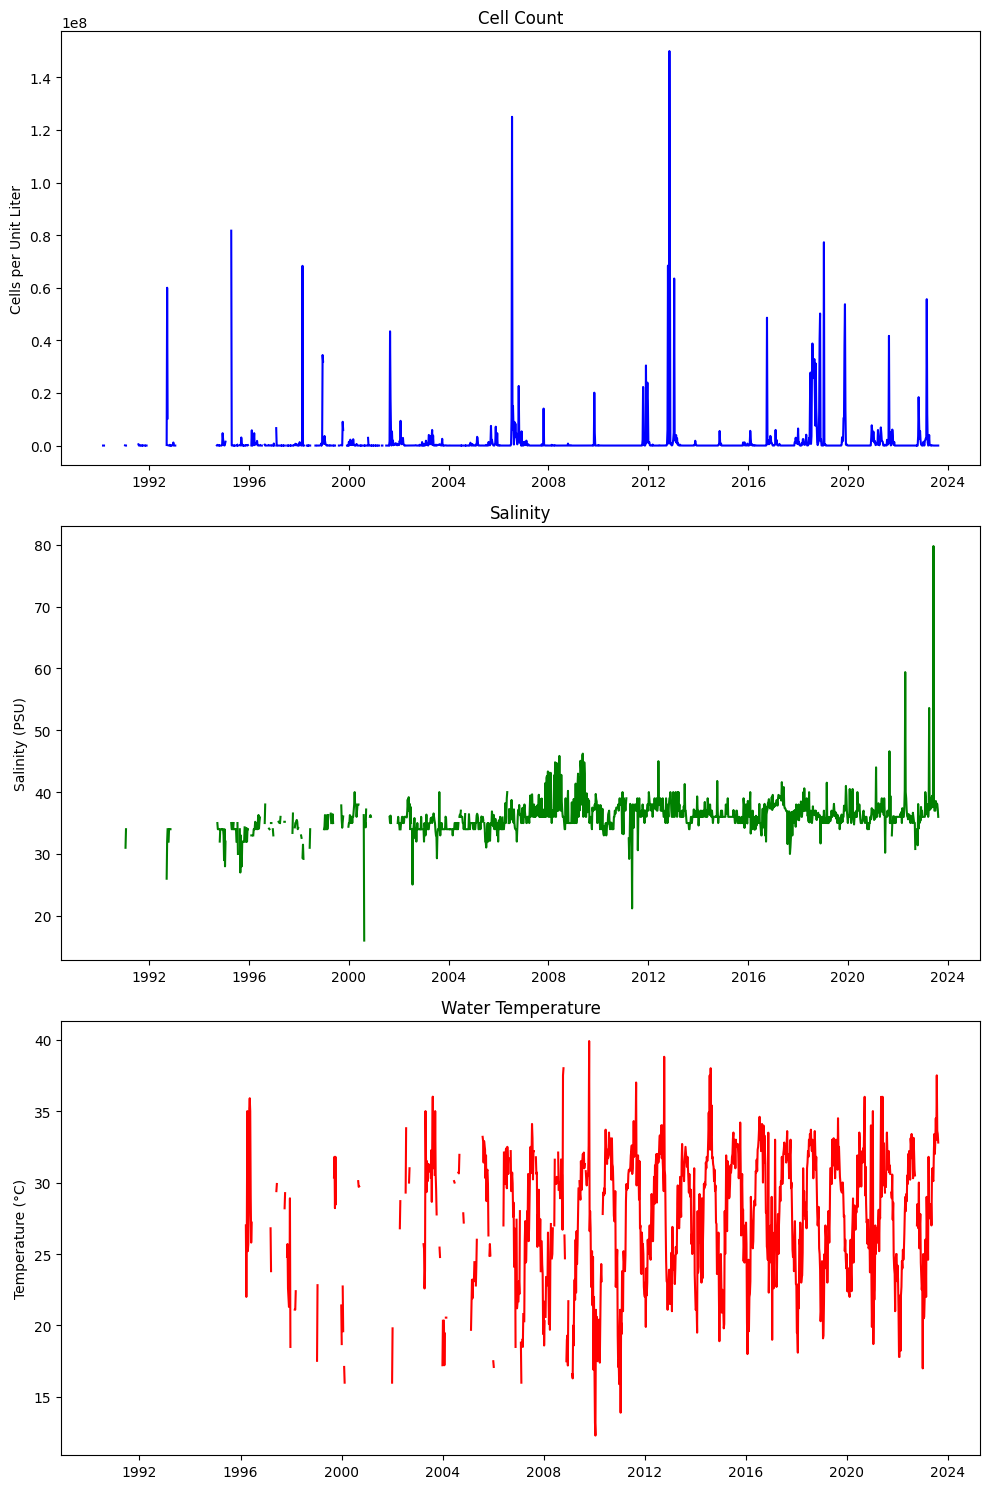


Resampled weekly data saved to 'input/hab_weekly.csv'


,CELLCOUNT,SALINITY,WATER_TEMP
time,,,
1990-01-01,NaN,NaN,NaN
1990-01-08,NaN,NaN,NaN
1990-01-15,NaN,NaN,NaN
1990-01-22,NaN,NaN,NaN
1990-01-29,NaN,NaN,NaN
...,...,...,...
2023-11-27,NaN,NaN,NaN
2023-12-04,NaN,NaN,NaN
2023-12-11,NaN,NaN,NaN


In [5]:
# Reading the CSV file
file_path = "../ocean/output/hab_charlotte_harbor_all.csv"
df = pd.read_csv(file_path)

# Convert SAMPLE_DATE to datetime
df['SAMPLE_DATE'] = pd.to_datetime(df['SAMPLE_DATE'])

# Set SAMPLE_DATE as the index
df.set_index('SAMPLE_DATE', inplace=True)

# Resample and compute maximum values for CELLCOUNT, SALINITY, and WATER_TEMP
weekly_hab = df.resample('W-MON').agg({
    'CELLCOUNT': 'max',
    'SALINITY': 'max',
    'WATER_TEMP': 'max'
})

# Create a complete weekly date range
complete_date_range = pd.date_range(start=StartDate, end=EndDate, freq='W-MON')

# Reindex the dataframe to this complete date range, filling missing data with NaNs
weekly_hab = weekly_hab.reindex(complete_date_range)

# Reset index to have the week start date as a column
weekly_hab.reset_index(inplace=True)
weekly_hab.rename(columns={'index': 'WEEK_START'}, inplace=True)

# Set WEEK_START as the index and rename it to 'time'
weekly_hab.set_index('WEEK_START', inplace=True)
weekly_hab.index.name = 'time'


# Create a 3x1 grid of subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# Plot CELLCOUNT on the first subplot
axs[0].plot(weekly_hab.index, weekly_hab['CELLCOUNT'], color='b')
axs[0].set_title('Cell Count')
axs[0].set_ylabel('Cells per Unit Liter')

# Plot SALINITY on the second subplot
axs[1].plot(weekly_hab.index, weekly_hab['SALINITY'], color='g')
axs[1].set_title('Salinity')
axs[1].set_ylabel('Salinity (PSU)')

# Plot WATER_TEMP on the third subplot
axs[2].plot(weekly_hab.index, weekly_hab['WATER_TEMP'], color='r')
axs[2].set_title('Water Temperature')
axs[2].set_ylabel('Temperature (°C)')

# Adjust layout for better fit
plt.tight_layout()

# Show the plots
plt.show()

# Save to CSV
output_file = 'input/hab_weekly.csv'
weekly_hab.to_csv(output_file)

# Display the first few rows to verify the result
print(f"\nResampled weekly data saved to '{output_file}'")
display(weekly_hab)

### 2.2 zos

#### 2.2.1 Weekly resampling

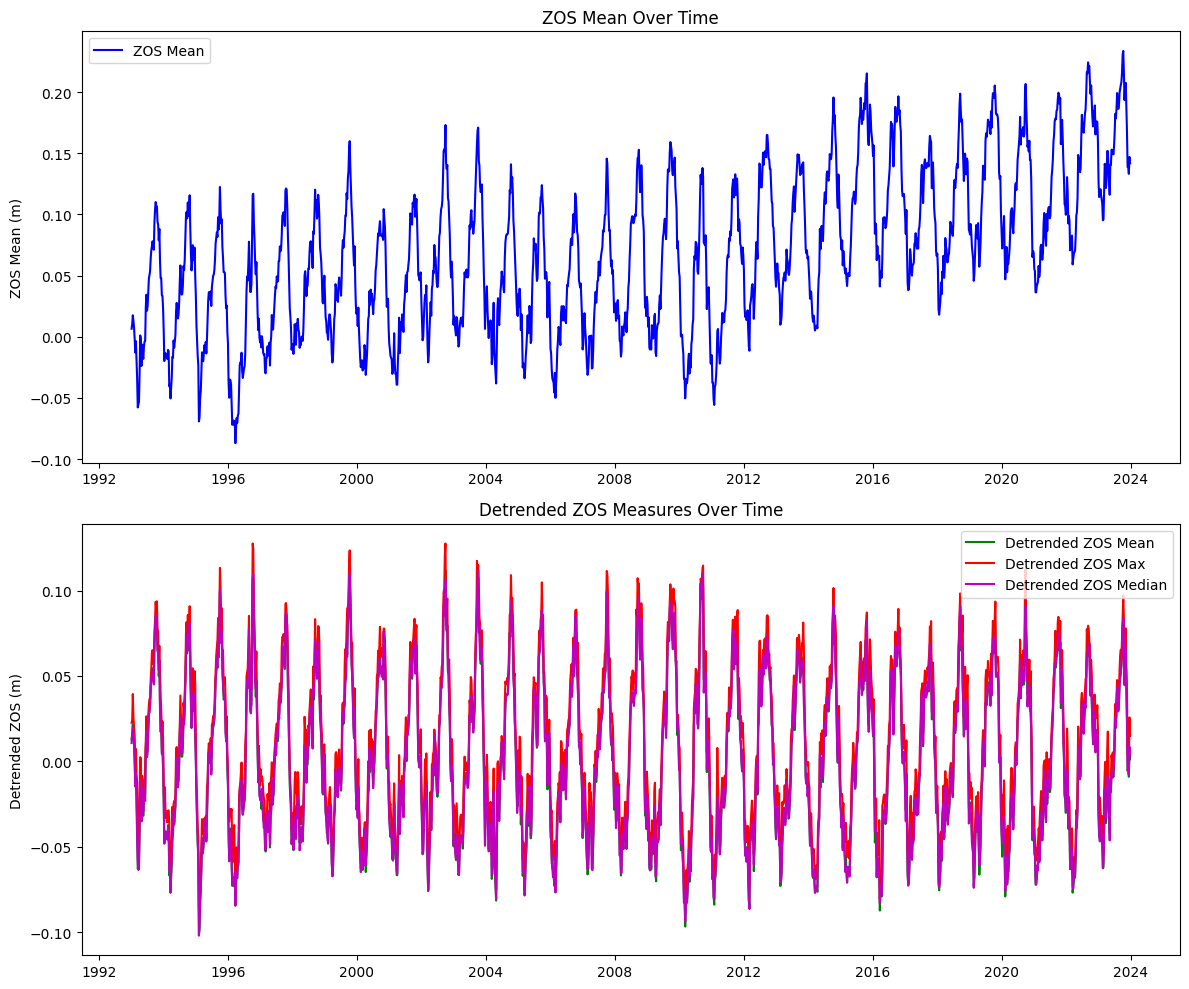

Extended resampled data saved to 'input/zos_weekly.csv'


,zos_mean,detrended_zos_mean,detrended_zos_max,detrended_zos_median
time,,,,
1990-01-01,NaN,NaN,NaN,NaN
1990-01-08,NaN,NaN,NaN,NaN
1990-01-15,NaN,NaN,NaN,NaN
1990-01-22,NaN,NaN,NaN,NaN
1990-01-29,NaN,NaN,NaN,NaN
...,...,...,...,...
2023-11-27,0.138694,-0.005114,0.003364,-0.005671
2023-12-04,0.138997,-0.003981,0.004709,-0.004344
2023-12-11,0.133151,-0.009013,-0.005218,-0.007787


In [6]:
# Reading the CSV file and parsing the dates
file_path = "../ocean/output/zos_daily.csv"
df = pd.read_csv(file_path, parse_dates=['time'], index_col='time')

# Resample zos to compute the weekly mean
zos_weekly_mean = df['zos'].resample('W-MON').mean()

# Resample detrended_zos using max
detrended_zos_mean = df['detrended_zos'].resample('W-MON').mean()

# Resample detrended_zos using max
detrended_zos_max = df['detrended_zos'].resample('W-MON').max()

# Resample detrended_zos using median
detrended_zos_median = df['detrended_zos'].resample('W-MON').median()

# Generate a complete weekly date range for the entire period
weekly_range = pd.date_range(start=StartDate, end=EndDate, freq='W-MON')

# Combine everything into a single DataFrame ensuring all weeks are present
weekly_zos = pd.DataFrame({
    'zos_mean': zos_weekly_mean,
    'detrended_zos_mean': detrended_zos_mean,
    'detrended_zos_max': detrended_zos_max,
    'detrended_zos_median': detrended_zos_median
}, index=weekly_range)

# Rename the index column
weekly_zos = weekly_zos.rename_axis('time')

# Limit the DataFrame to the specified date range
weekly_zos = weekly_zos.loc[StartDate:EndDate]


# Create a 2x1 grid of subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Plot zos_mean on the first subplot
axs[0].plot(weekly_zos.index, weekly_zos['zos_mean'], color='b', label='ZOS Mean')
axs[0].set_title('ZOS Mean Over Time')
axs[0].set_ylabel('ZOS Mean (m)')
axs[0].legend(loc='best')

# Plot detrended_zos_mean, detrended_zos_max, and detrended_zos_median on the second subplot
axs[1].plot(weekly_zos.index, weekly_zos['detrended_zos_mean'], color='g', label='Detrended ZOS Mean')
axs[1].plot(weekly_zos.index, weekly_zos['detrended_zos_max'], color='r', label='Detrended ZOS Max')
axs[1].plot(weekly_zos.index, weekly_zos['detrended_zos_median'], color='m', label='Detrended ZOS Median')
axs[1].set_title('Detrended ZOS Measures Over Time')
axs[1].set_ylabel('Detrended ZOS (m)')
axs[1].legend(loc='best')

# Adjust layout for better fit
plt.tight_layout()

# Show the plots
plt.show()

# Save the resulting DataFrame to a new CSV file
output_file = "input/zos_weekly.csv"
weekly_zos.to_csv(output_file)

print(f"Extended resampled data saved to '{output_file}'")
display(weekly_zos)

## 3. River

### 3.1 Peace river discharge

In [7]:
# Reading the CSV file and parsing the dates
file_path = "../river/input/peace_river_discharge_arcadia.csv"
df = pd.read_csv(file_path, parse_dates=['datetime'], index_col='datetime')

# Ensure the DataFrame is sorted by the datetime index
df.sort_index(inplace=True)

# Resample the data to weekly frequency and calculate mean and max
weekly_pc_dis = df['00060'].resample('W-MON').agg(['mean', 'max'])

# Limit the DataFrame to the specified date range
weekly_pc_dis = weekly_pc_dis.loc[StartDate:EndDate]

# Rename the columns to match the desired output format
weekly_pc_dis.rename(columns={'mean': 'discharge_mean', 'max': 'discharge_max'}, inplace=True)

# Create additional columns for deviations from the mean
weekly_pc_dis['discharge_meanDev'] = weekly_pc_dis['discharge_mean'] - weekly_pc_dis['discharge_mean'].mean()
weekly_pc_dis['discharge_maxDev'] = weekly_pc_dis['discharge_max'] - weekly_pc_dis['discharge_max'].mean()

# Rename the index to 'time'
# Convert the datetime index to a date format (YYYY-MM-DD)
weekly_pc_dis.index.name = 'time'
weekly_pc_dis.index = weekly_pc_dis.index.strftime('%Y-%m-%d')
weekly_pc_dis.index = pd.to_datetime(weekly_pc_dis.index)

# Save the resulting DataFrame to a new CSV file
output_file = "input/discharge_peace_weekly.csv"
weekly_pc_dis.to_csv(output_file)

print(f"Resampled data saved to '{output_file}'")
display(weekly_pc_dis)

Resampled data saved to 'input/discharge_peace_weekly.csv'


,discharge_mean,discharge_max,discharge_meanDev,discharge_maxDev
time,,,,
1990-01-01,NaN,NaN,NaN,NaN
1990-01-08,NaN,NaN,NaN,NaN
1990-01-15,NaN,NaN,NaN,NaN
1990-01-22,NaN,NaN,NaN,NaN
1990-01-29,NaN,NaN,NaN,NaN
...,...,...,...,...
2023-11-27,273.932127,326.0,-749.387421,-1041.917759
2023-12-04,210.825472,231.0,-812.494076,-1136.917759
2023-12-11,183.182371,201.0,-840.137177,-1166.917759


#### Plot discharge

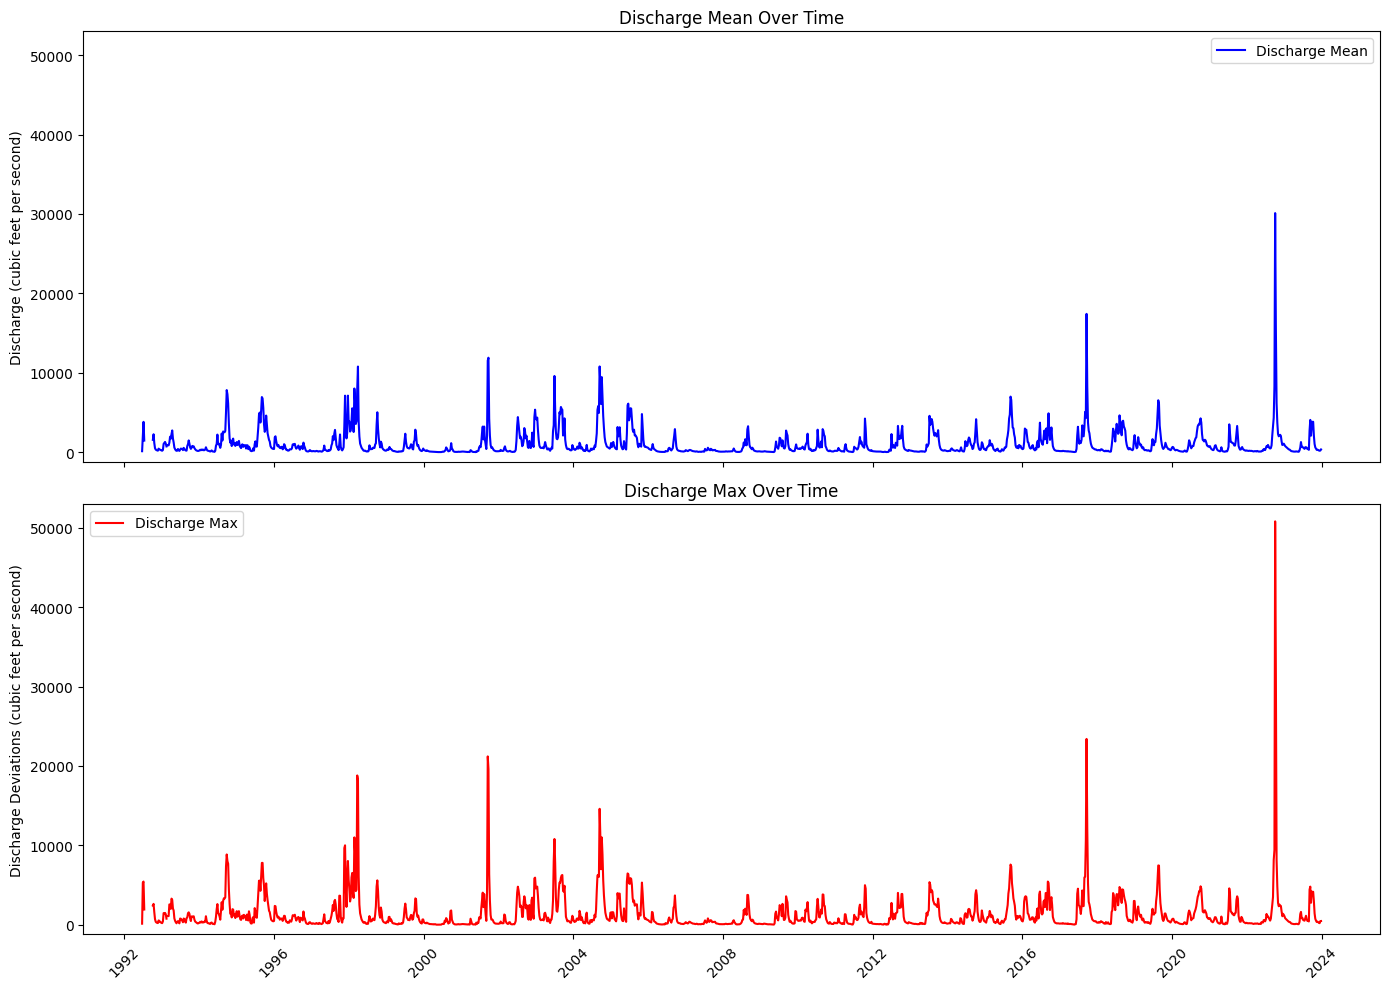

In [8]:
# Step 3: Create a 2x1 grid of subplots
common_y_range = (-1200, 5.3e4)
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Step 4: Plot discharge_mean on the first subplot
axs[0].plot(weekly_pc_dis.index, weekly_pc_dis['discharge_mean'], color='b', label='Discharge Mean')
axs[0].set_title('Discharge Mean Over Time')
axs[0].set_ylabel('Discharge (cubic feet per second)')
axs[0].set_ylim(common_y_range)
axs[0].legend(loc='best')

# Step 5: Plot discharge_max on the second subplot
axs[1].plot(weekly_pc_dis.index, weekly_pc_dis['discharge_max'], color='r', label='Discharge Max')
axs[1].set_title('Discharge Max Over Time')
axs[1].set_ylabel('Discharge Deviations (cubic feet per second)')
axs[1].set_ylim(common_y_range)
axs[1].legend(loc='best')

# # Step 6: Set x-axis range manually (force matplotlib to obey)
# start_date = weekly_pc_dis_nan.index.min()
# end_date = weekly_pc_dis_nan.index.max()
# axs[0].set_xlim([start_date, end_date])
# axs[1].set_xlim([start_date, end_date])

# Step 7: Improve x-axis formatting
locator = mdates.YearLocator(4)  # Every 5 years
formatter = mdates.DateFormatter('%Y')

for ax in axs:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(axis='x', rotation=45)

# Step 8: Fix layout and overlap issues
plt.tight_layout()

# Step 9: Show plot
plt.show()


### 3.2 Peace river TN and TP

In [9]:
basinID='03100101'
file_path = f'../river/input/HU8_{basinID}_TN_TP.csv'  # Adjust path if needed
df = pd.read_csv(file_path)

# Separate TN and TP data
tn_data = df[df['Parameter'].isin(['TN_mgl', 'TN_ugl'])]
tp_data = df[df['Parameter'].isin(['TP_mgl', 'TP_ugl'])]

# Convert concentration to consistent units (mg/L) if necessary
tn_data.loc[tn_data['Parameter'] == 'TN_ugl', 'Result_Value'] /= 1000
tp_data.loc[tp_data['Parameter'] == 'TP_ugl', 'Result_Value'] /= 1000

# Ensure 'SampleDate' is converted to datetime
tn_data['SampleDate'] = pd.to_datetime(tn_data['SampleDate'])
tp_data['SampleDate'] = pd.to_datetime(tp_data['SampleDate'])

# Sort the data by 'SampleDate', set 'SampleDate' as the index and rename it to 'time'
tn_data = tn_data.sort_values('SampleDate').set_index('SampleDate').rename_axis('time')
tp_data = tp_data.sort_values('SampleDate').set_index('SampleDate').rename_axis('time')

# Lower and upper data

# Create a new column in tp_data
tn_data['Lat_TN'] = np.where(tn_data['Actual_Latitude'] <= 27.4, 0, 1)
tp_data['Lat_TP'] = np.where(tp_data['Actual_Latitude'] <= 27.4, 0, 1)

# Select relevant columns (Result_Value) from each DataFrame
tn_results = tn_data[['Result_Value','Lat_TN']].rename(columns={'Result_Value': 'TN'})
tp_results = tp_data[['Result_Value','Lat_TP']].rename(columns={'Result_Value': 'TP'})

# Join both DataFrames on their time index
data = tn_results.join(tp_results, how='outer') 

# Display the combined DataFrame
#display(data.loc[StartDate:EndDate])

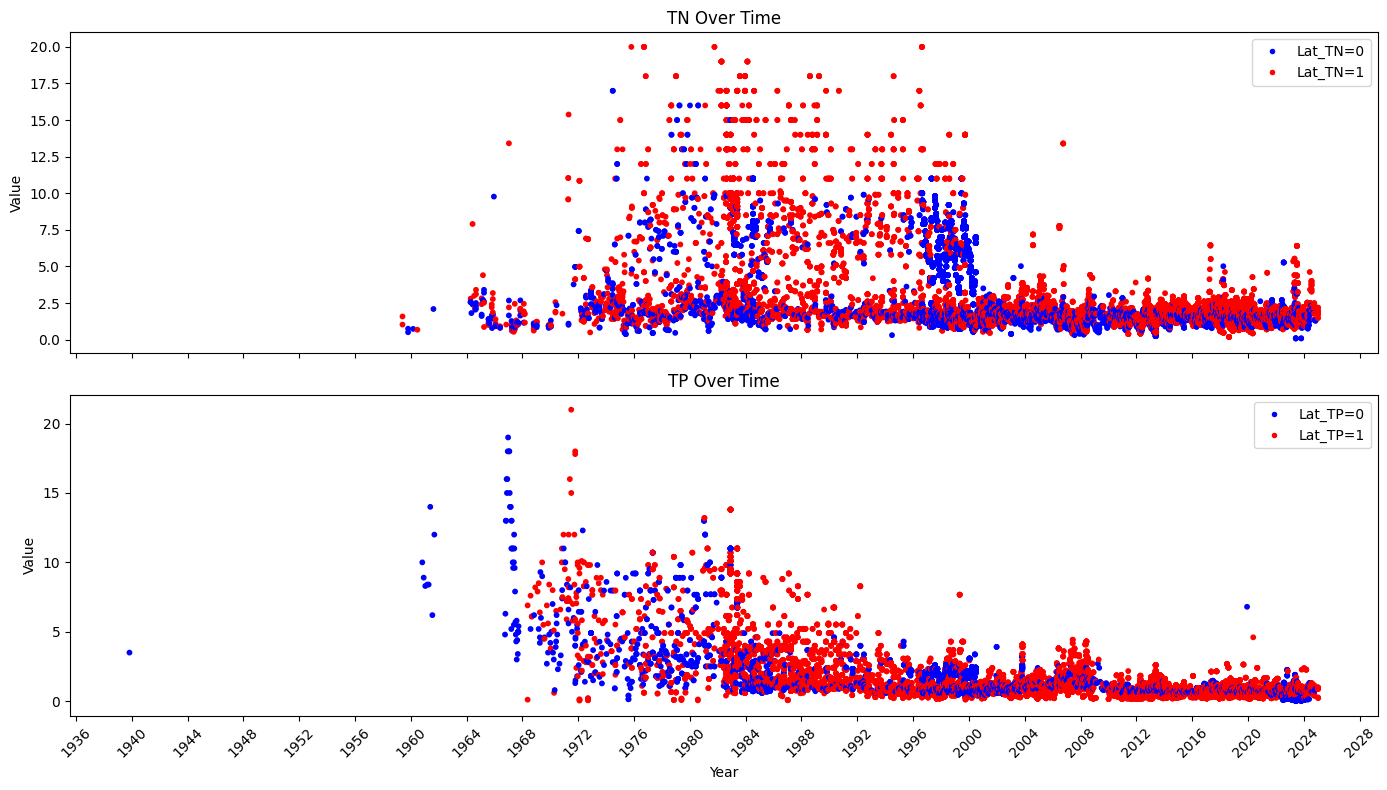

In [10]:
# Fill NaN values before mapping to colors
# You can choose to fill with a specific category, here I am adding a new category for NaN values as 'grey'
data['Lat_TN_filled'] = data['Lat_TN'].fillna(-1).map({0: 'blue', 1: 'red', -1: 'black'})
data['Lat_TP_filled'] = data['Lat_TP'].fillna(-1).map({0: 'blue', 1: 'red', -1: 'black'})

# Create a 2x1 grid of subplots
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Scatter plot for TN
lat_tn_colors = data['Lat_TN_filled']
axs[0].scatter(data.index, data['TN'], s=10, c=lat_tn_colors)
axs[0].set_title('TN Over Time')
axs[0].set_ylabel('Value')
axs[0].xaxis.set_major_locator(mdates.YearLocator(4))  # Set major ticks every 4 years
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format ticks as years
axs[0].legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Lat_TN=0', markerfacecolor='blue', markersize=5),
    plt.Line2D([0], [0], marker='o', color='w', label='Lat_TN=1', markerfacecolor='red', markersize=5),
], loc='upper right')

# Scatter plot for TP
lat_tp_colors = data['Lat_TP_filled']
axs[1].scatter(data.index, data['TP'], s=10, c=lat_tp_colors)
axs[1].set_title('TP Over Time')
axs[1].set_ylabel('Value')
axs[1].set_xlabel('Year')
axs[1].legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Lat_TP=0', markerfacecolor='blue', markersize=5),
    plt.Line2D([0], [0], marker='o', color='w', label='Lat_TP=1', markerfacecolor='red', markersize=5),
], loc='upper right')
axs[1].xaxis.set_major_locator(mdates.YearLocator(4))  # Set major ticks every 4 years
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format ticks as years

# Rotate date labels for better visibility
plt.setp(axs[1].xaxis.get_majorticklabels(), rotation=45)

# Adjust layout for better fit
plt.tight_layout()

# Show the plots
plt.show()

In [11]:
# Resample the original data by week, calculating both mean and max
resampled_mean = data.resample('W-MON').mean(numeric_only=True) \
.rename(columns={'TN': 'TN_mean','TP': 'TP_mean'})
resampled_max = data.resample('W-MON').max(numeric_only=True)  \
.rename(columns={'TN': 'TN_max','TP': 'TP_max'})

# Slice the resampled data for the desired date range
weekly_mean = resampled_mean.loc[StartDate:EndDate]
weekly_max = resampled_max.loc[StartDate:EndDate]

# Create the weekly_pc_nut DataFrame
weekly_pc_nut = pd.DataFrame(index=weekly_mean.index)
weekly_pc_nut['TN_mean'] = weekly_mean['TN_mean']
weekly_pc_nut['TN_max'] = weekly_max['TN_max']
weekly_pc_nut['TP_mean'] = weekly_mean['TP_mean']
weekly_pc_nut['TP_max'] = weekly_max['TP_max']

display(weekly_pc_nut)

,TN_mean,TN_max,TP_mean,TP_max
time,,,,
1990-01-01,NaN,NaN,NaN,NaN
1990-01-08,NaN,NaN,NaN,NaN
1990-01-15,NaN,NaN,NaN,NaN
1990-01-22,NaN,NaN,NaN,NaN
1990-01-29,1.980000,1.980,NaN,NaN
...,...,...,...,...
2023-11-27,NaN,NaN,NaN,NaN
2023-12-04,2.180000,2.180,0.800000,0.80
2023-12-11,1.840000,1.840,0.790000,0.79


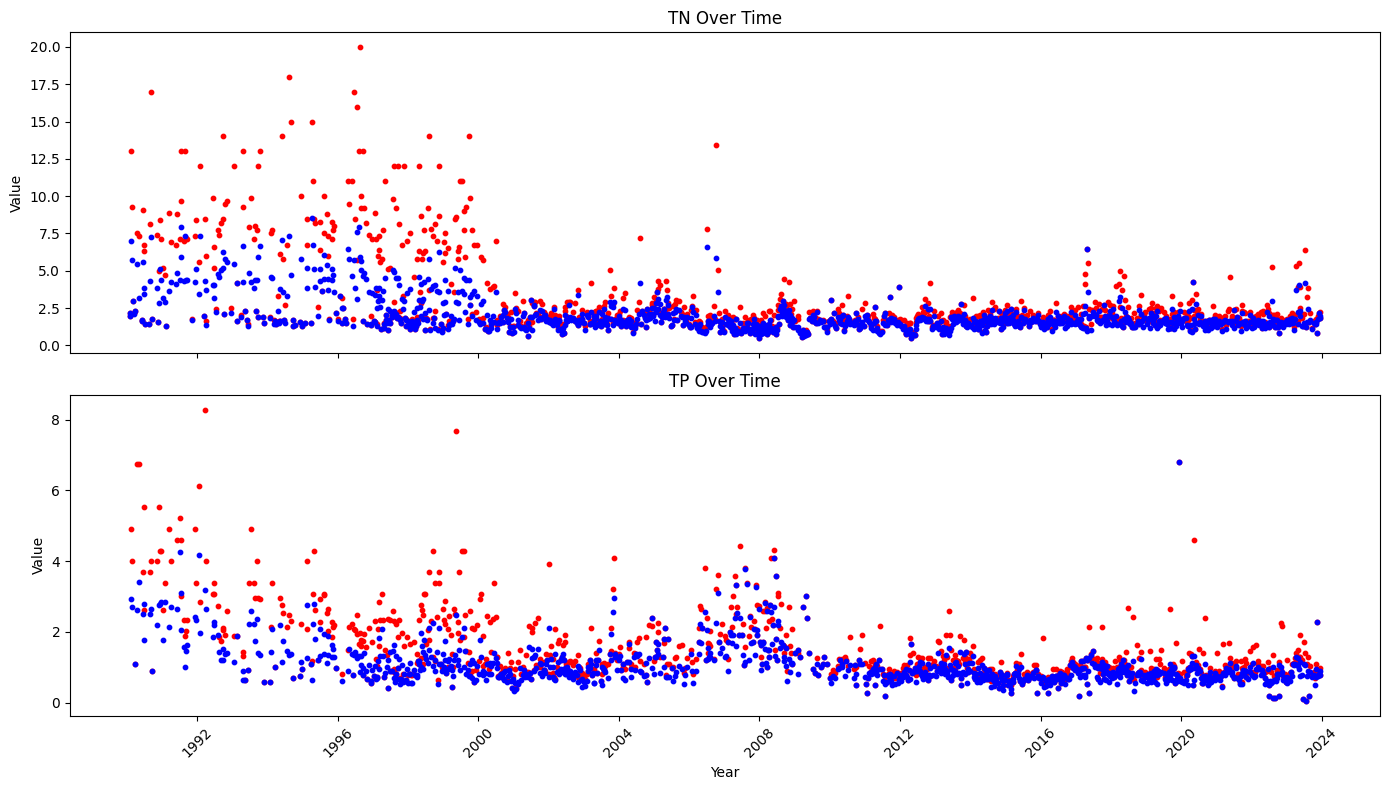

In [12]:
# Create a 2x1 grid of subplots
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Scatter plot for TN
axs[0].scatter(weekly_pc_nut.index, weekly_pc_nut['TN_max'], s=10, c='red',label='max')
axs[0].scatter(weekly_pc_nut.index, weekly_pc_nut['TN_mean'], s=10, c='blue',label='mean')
axs[0].set_title('TN Over Time')
axs[0].set_ylabel('Value')
axs[0].xaxis.set_major_locator(mdates.YearLocator(4))  # Set major ticks every 4 years
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format ticks as years

# Scatter plot for TP
axs[1].scatter(weekly_pc_nut.index, weekly_pc_nut['TP_max'], s=10, c='red',label='max')
axs[1].scatter(weekly_pc_nut.index, weekly_pc_nut['TP_mean'], s=10, c='blue',label='mean')
axs[1].set_title('TP Over Time')
axs[1].set_ylabel('Value')
axs[1].set_xlabel('Year')
axs[1].xaxis.set_major_locator(mdates.YearLocator(4))  # Set major ticks every 4 years
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format ticks as years

# Rotate date labels for better visibility
plt.setp(axs[1].xaxis.get_majorticklabels(), rotation=45)

# Adjust layout for better fit
plt.tight_layout()

# Show the plots
plt.show()

## 4. Collect dataset

### 4.1 Display data

Display data to select columns to be combined and check start and end date

In [13]:
#Display datasets
rows_to_show=[0,1,-2, -1]
display(weekly_wind.iloc[rows_to_show], weekly_wind.shape)
display(weekly_hab.iloc[rows_to_show], weekly_hab.shape)
display(weekly_zos.iloc[rows_to_show], weekly_zos.shape)
display(weekly_pc_dis.iloc[rows_to_show], weekly_pc_dis.shape)
display(weekly_pc_nut.iloc[rows_to_show], weekly_pc_nut.shape)

,WDIR_mean,WDIR_median,WDIR_mode,WSPD,ATMP,WTMP
time,,,,,,
1990-01-01,9.895843,328.282768,15.0,12.2,25.3,26.1
1990-01-08,133.922631,137.632056,113.0,12.9,26.1,26.1
2023-12-18,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-25,NaN,NaN,NaN,NaN,NaN,NaN


(1774, 6)

,CELLCOUNT,SALINITY,WATER_TEMP
time,,,
1990-01-01,NaN,NaN,NaN
1990-01-08,NaN,NaN,NaN
2023-12-18,NaN,NaN,NaN
2023-12-25,NaN,NaN,NaN


(1774, 3)

,zos_mean,detrended_zos_mean,detrended_zos_max,detrended_zos_median
time,,,,
1990-01-01,NaN,NaN,NaN,NaN
1990-01-08,NaN,NaN,NaN,NaN
2023-12-18,0.146926,0.005557,0.025714,0.008546
2023-12-25,0.141837,0.001243,0.014987,0.002676


(1774, 4)

,discharge_mean,discharge_max,discharge_meanDev,discharge_maxDev
time,,,,
1990-01-01,NaN,NaN,NaN,NaN
1990-01-08,NaN,NaN,NaN,NaN
2023-12-18,204.811263,460.0,-818.508284,-907.917759
2023-12-25,344.843609,470.0,-678.475939,-897.917759


(1774, 4)

,TN_mean,TN_max,TP_mean,TP_max
time,,,,
1990-01-01,NaN,NaN,NaN,NaN
1990-01-08,NaN,NaN,NaN,NaN
2023-12-18,1.956353,2.208,0.884941,0.97
2023-12-25,NaN,NaN,NaN,NaN


(1774, 4)

###  4.2 Interpolate temperature data from NOAA Bouy and KB data

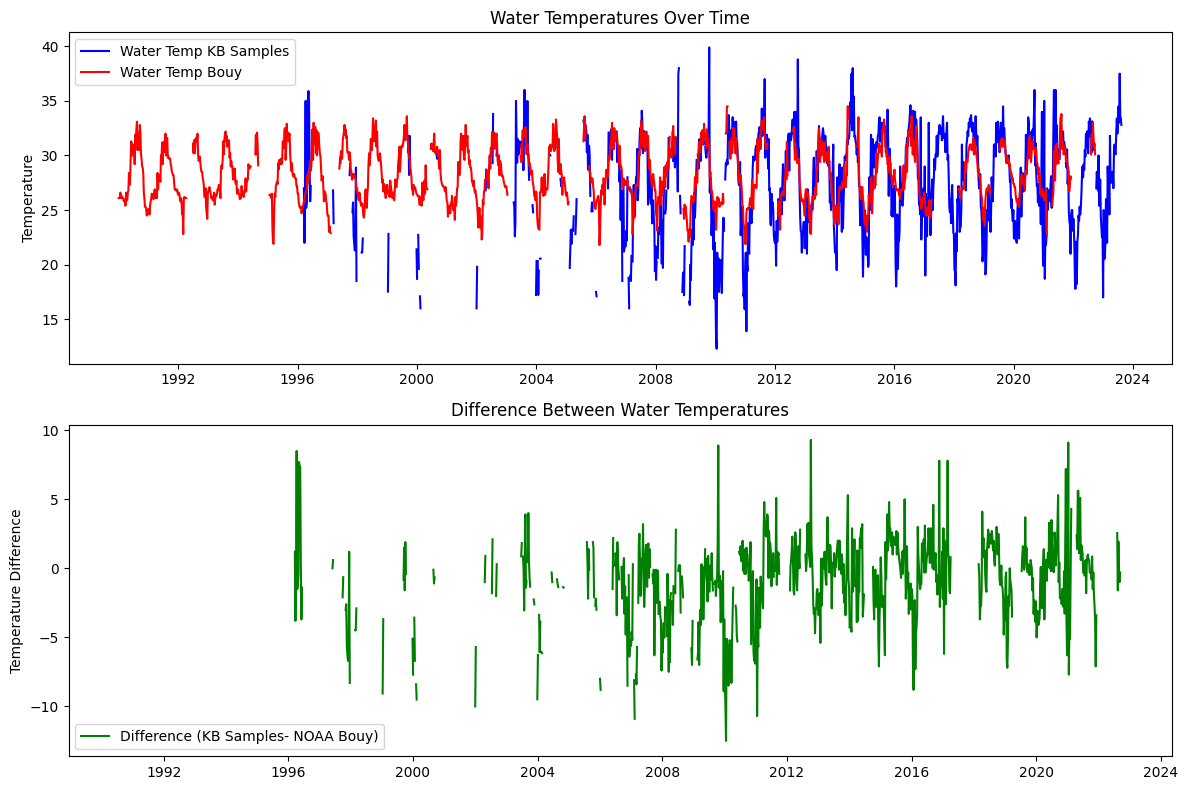

In [14]:
# Define the figure and subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 8))
# weekly_wind: WDIR_mean	WDIR_median	WDIR_mode	WSPD	ATMP	WTMP
# weekly_hab: CELLCOUNT	SALINITY	WATER_TEMP

# Plot water_temp_kb and water_temp on the first subplot
axs[0].plot(weekly_hab.index, weekly_hab['WATER_TEMP'], label='Water Temp KB Samples', color='b')
axs[0].plot(weekly_wind.index, weekly_wind['WTMP'], label='Water Temp Bouy', color='r')
axs[0].set_title('Water Temperatures Over Time')
axs[0].set_ylabel('Temperature')
axs[0].legend(loc='best')

# Plot the difference on the second subplot
axs[1].plot(weekly_hab.index, weekly_hab['WATER_TEMP'] - weekly_wind['WTMP'], label='Difference (KB Samples- NOAA Bouy)', color='g')
axs[1].set_title('Difference Between Water Temperatures')
axs[1].set_ylabel('Temperature Difference')
axs[1].legend(loc='best')

# Adjust layout for better fit and display the plot
plt.tight_layout()
plt.show()

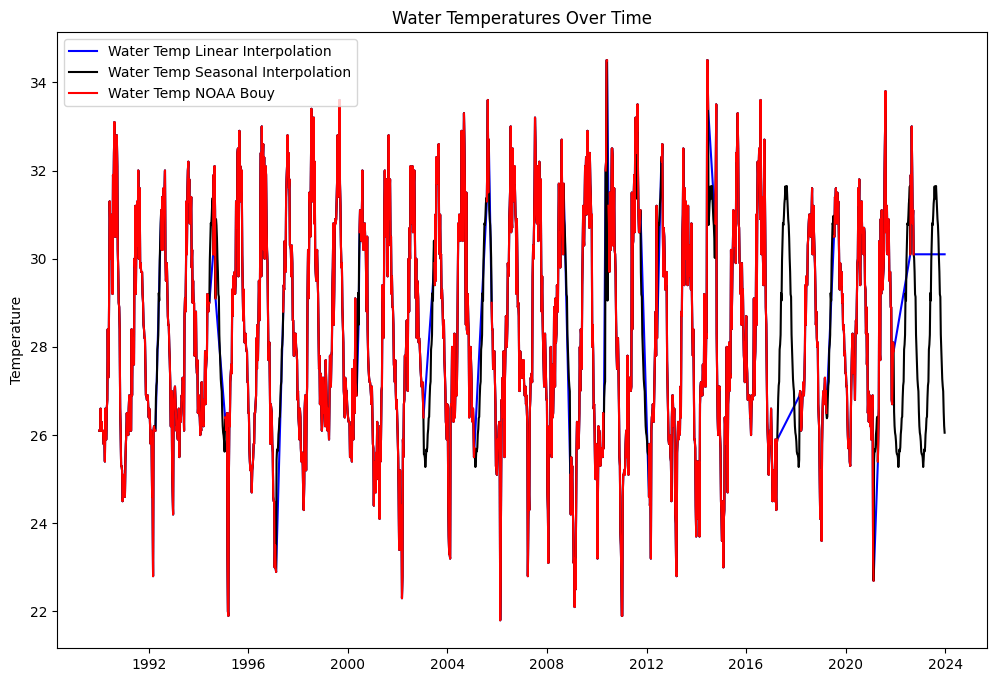

In [15]:
# weekly_wind: WDIR_mean	WDIR_median	WDIR_mode	WSPD	ATMP	WTMP
# weekly_hab: CELLCOUNT	SALINITY	WATER_TEMP

weekly_wind['water_temp_ln'] = weekly_wind['WTMP'].interpolate(method='linear')

# Fill with mean for the same week across years
weekly_wind['water_temp_sn'] =  weekly_wind['WTMP'].fillna(
    weekly_wind.groupby(weekly_wind.index.isocalendar().week)['WTMP'].transform('mean')
)
# df_combined['water_temp_mix']=df_combined['water_temp_kb'].interpolate(method='linear')
# df_combined.loc[StartDate:'2021-12-06', 'water_temp_mix']= df_combined.loc[StartDate:'2021-12-06','water_temp_sn'] 

# Define the figure and subplots
fig, axs = plt.subplots(1, 1, figsize=(12, 8))
# Plot water_temp_kb and water_temp on the first subplot
axs.plot(weekly_wind.index, weekly_wind['water_temp_ln'], label='Water Temp Linear Interpolation', color='b')
axs.plot(weekly_wind.index, weekly_wind['water_temp_sn'], label='Water Temp Seasonal Interpolation', color='k')
#axs.plot(df_combined.index, df_combined['water_temp_mix'], label='Water Temp Mixed Interpolation', color='g')
axs.plot(weekly_wind.index, weekly_wind['WTMP'], label='Water Temp NOAA Bouy', color='r')
axs.set_title('Water Temperatures Over Time')
axs.set_ylabel('Temperature')
axs.legend(loc='best')


## 5. Combine datasets 

Combine datasets into one dataFrame for based on data selected for each feature, which can result in multiple datasets

### 5.1 Select columns to be combinded

In [16]:
def combine(var_kb, var_sal, var_temp, var_wdir, var_wspd, var_zos, var_dis_pc, var_TN_pc, var_TP_pc):
    df_combined = pd.DataFrame()
    
    # CELLCOUNT -> kb
    df_combined['kb'] = weekly_hab[var_kb]
    
    # 1) SALINITY -> salinity
    df_combined['salinity'] = weekly_hab[var_sal]
    
    # 2) WTMP -> water_temp
    df_combined['water_temp'] = weekly_wind[var_temp]
    
    # 3) WDIR_mean OR WDIR_median OR WDIR_mode -> wind_direction
    var='WDIR_mode'  #'WDIR_mean', 'WDIR_median', 'WDIR_mode'
    df_combined['wind_direction'] = weekly_wind[var_wdir]
    
    # 4) WSPD -> wind_speed
    df_combined['wind_speed'] = weekly_wind[var_wspd]
    
    # 5) zos_mean OR detrended_zos_mean OR detrended_zos_max OR detrended_zos_median -> zos sea surface height
    #var= 'detrended_zos_mean' #'zos_mean','detrended_zos_mean', 'detrended_zos_max', 'detrended_zos_median'
    df_combined['zos'] = weekly_zos[var_zos]
    
    # 6) discharge_mean OR discharge_max OR discharge_meanDev OR discharge_maxDev -> peace river discharge
    #var= 'discharge_max'#'discharge_mean', 'discharge_max', 'discharge_meanDev', 'discharge_maxDev'
    df_combined['peace_discharge'] = weekly_pc_dis[var_dis_pc]
    
    # 7) TN_mean OR TN_max -> peace river TN
    #var='TN_max' # 'TN_mean', 'TN_max'  
    df_combined['peace_TN'] = weekly_pc_nut[var_TN_pc]
    
    # 8) TP_mean OR TP_max -> peace_TP
    #var='TP_max' # 'TP_mean', 'TP_max'  
    df_combined['peace_TP'] = weekly_pc_nut[var_TP_pc]
    
    # Ensure the index is named `time` if it's not already
    df_combined.index.name = 'time'

    return df_combined

In [17]:
# Define a dictionary to hold column selections for each category
column_selections = {
    'kb': ['CELLCOUNT'],
    'wsalinity': ['SALINITY'],
    'wtemp': ['water_temp_sn'],
    'wdir': ['WDIR_mean', 'WDIR_median', 'WDIR_mode'],
    'wspeed': ['WSPD'],
    'zos': ['zos_mean', 'detrended_zos_mean', 'detrended_zos_max', 'detrended_zos_median'],
    'dis_pc': ['discharge_mean', 'discharge_max', 'discharge_meanDev', 'discharge_maxDev'],
    'TN_pc': ['TN_mean', 'TN_max'],
    'TP_pc': ['TP_mean', 'TP_max']
}

# Define the indices for selection
select = [0, 0, 0, 2, 0, 1, 1, 1, 1]

# Combine the selected columns into a DataFrame
df_combined = combine(
    *[column_selections[key][select[i]] for i, key in enumerate(column_selections)]
)

# Create the filename based on selection indices
filename_indices = ''.join(f'{key[1].upper()}{select[i]}' for i, key in enumerate(column_selections))
output_file = f"input/data_weekly_{filename_indices}.csv"

# Save the resulting DataFrame to a new CSV file
df_combined.to_csv(output_file)

print(f"Combined data saved to '{output_file}'")
display(df_combined)

Combined data saved to 'input/data_weekly_B0S0T0D2S0O1I1N1P1.csv'


,kb,salinity,water_temp,wind_direction,wind_speed,zos,peace_discharge,peace_TN,peace_TP
time,,,,,,,,,
1990-01-01,NaN,NaN,26.100000,15.0,12.2,NaN,NaN,NaN,NaN
1990-01-08,NaN,NaN,26.100000,113.0,12.9,NaN,NaN,NaN,NaN
1990-01-15,NaN,NaN,26.100000,95.0,11.3,NaN,NaN,NaN,NaN
1990-01-22,NaN,NaN,26.600000,105.0,11.0,NaN,NaN,NaN,NaN
1990-01-29,NaN,NaN,26.100000,117.0,16.4,NaN,NaN,1.980,NaN
...,...,...,...,...,...,...,...,...,...
2023-11-27,NaN,NaN,27.110714,NaN,NaN,-0.005114,326.0,NaN,NaN
2023-12-04,NaN,NaN,26.992857,NaN,NaN,-0.003981,231.0,2.180,0.80
2023-12-11,NaN,NaN,26.528571,NaN,NaN,-0.009013,201.0,1.840,0.79


### 5.2 Interpolate data
- Linear interpolation: salinty, wind_direction, wind_speed, peace_discharge, peace_TN, peace_TP, 
- Fill with zero: KB


In [18]:
df_interpol = df_combined[['kb', 'zos', 'salinity', 'water_temp', 
                             'wind_direction', 'wind_speed', 
                             'peace_discharge', 'peace_TN', 'peace_TP']].copy()

# Rename 'water_temp_sn' to 'water_temp'
df_interpol = df_interpol.rename(columns={'water_temp_sn': 'water_temp'})

# Fill NaN in 'kb' with 0
df_interpol['kb'].fillna(0, inplace=True)

# Linear interpolation on specified columns
df_interpol[['salinity', 'peace_discharge', 'peace_TN', 'peace_TP']]  \
            = df_interpol[['salinity', 'peace_discharge', 'peace_TN', 'peace_TP']].interpolate(method='linear')


# Fill with mean for the same week across years
df_interpol['wind_direction'] = df_interpol['wind_direction'].fillna(
    df_combined.groupby(df_combined.index.isocalendar().week)['wind_direction'].transform('mean'))

df_interpol['wind_speed'] = df_interpol['wind_speed'].fillna(
    df_combined.groupby(df_combined.index.isocalendar().week)['wind_speed'].transform('mean'))



#Set start date and end date
start_date='1993-01-01'
end_date='2023-12-31'
df_interpol=df_interpol.loc[start_date:end_date,:]

# Save and display df_interpol
print(f"Intepolated data saved to '{output_file}'")
df_interpol.to_csv('input/data_weekly_intepolated.csv')

# Displaying the DataFrame
display(df_interpol)

#summary_stats
display(df_interpol.describe())

Intepolated data saved to 'input/data_weekly_B0S0T0D2S0O1I1N1P1.csv'


,kb,zos,salinity,water_temp,wind_direction,wind_speed,peace_discharge,peace_TN,peace_TP
time,,,,,,,,,
1993-01-04,333.0,0.012906,33.043478,26.800000,36.000000,13.900000,202.0,8.2000,1.999091
1993-01-11,667.0,0.015614,33.065217,27.000000,118.000000,16.200000,423.0,10.1000,1.934545
1993-01-18,667.0,0.021702,33.086957,27.100000,108.000000,16.200000,1470.0,12.0000,1.870000
1993-01-25,0.0,0.015950,33.108696,26.800000,110.000000,12.600000,1450.0,10.0475,1.870500
1993-02-01,0.0,0.008977,33.130435,26.500000,14.000000,17.500000,1490.0,8.0950,1.871000
...,...,...,...,...,...,...,...,...,...
2023-11-27,0.0,-0.005114,36.000000,27.110714,79.800000,11.666667,326.0,2.0675,0.836500
2023-12-04,0.0,-0.003981,36.000000,26.992857,91.466667,12.306667,231.0,2.1800,0.800000
2023-12-11,0.0,-0.009013,36.000000,26.528571,83.833333,12.086667,201.0,1.8400,0.790000


,kb,zos,salinity,water_temp,wind_direction,wind_speed,peace_discharge,peace_TN,peace_TP
count,1.617000e+03,1617.000000,1617.000000,1617.000000,1617.000000,1617.000000,1617.000000,1617.000000,1617.000000
mean,1.438820e+06,0.001081,35.790494,28.261448,108.228236,11.646628,1367.712245,2.760305,1.376341
std,7.904052e+06,0.045056,2.634435,2.396945,73.549966,2.934444,2471.245893,2.473869,0.775845
min,0.000000e+00,-0.101714,16.000000,21.800000,0.000000,2.100000,9.100000,0.470000,0.040000
25%,0.000000e+00,-0.036704,34.492857,26.400000,66.000000,9.700000,198.000000,1.560000,0.858500
50%,3.330000e+02,-0.002629,36.000000,27.942308,97.892857,11.500000,606.000000,1.880500,1.125000
75%,1.370830e+05,0.038149,37.000000,30.400000,124.142857,13.189655,1560.000000,2.595000,1.688000
max,1.500000e+08,0.111739,79.780000,34.500000,360.000000,28.600000,50800.000000,20.000000,7.670000


### 5.3 Plot final data for ML

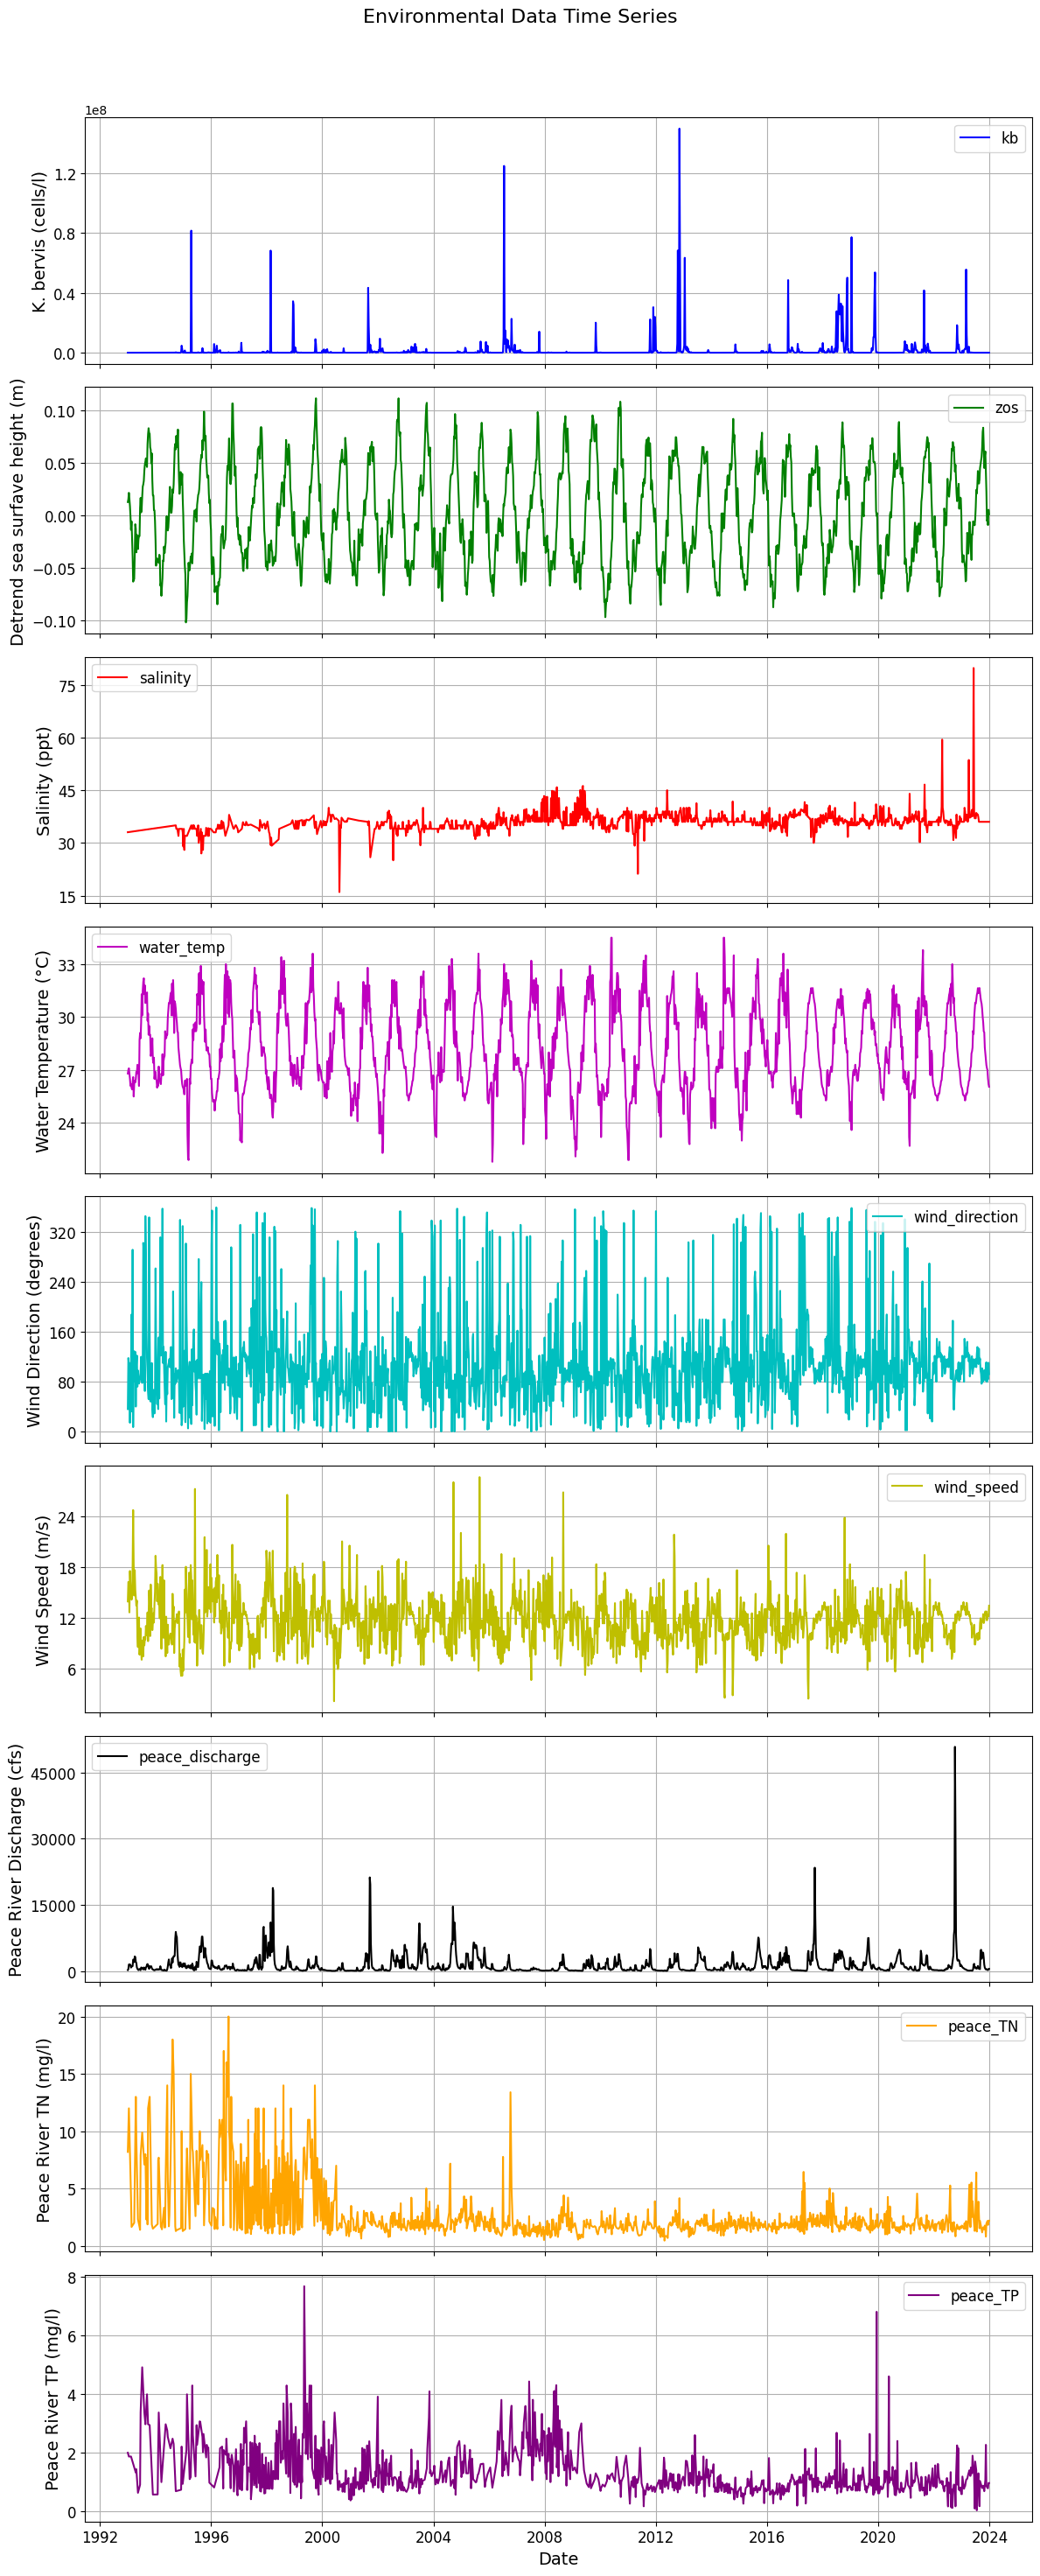

In [22]:
# Assuming df_interpol is already defined
# df_interpol = pd.DataFrame({...})  # Replace with your actual DataFrame

# Set the index to ensure the time series is on the x-axis
df_interpol.index = pd.to_datetime(df_interpol.index)

# Prepare subplot parameters
variables = [
    {'key': 'kb', 'color': 'b', 'label': 'K. bervis (cells/l)'},
    {'key': 'zos', 'color': 'g', 'label': 'Detrend sea surfave height (m)'}, 
    {'key': 'salinity', 'color': 'r', 'label': 'Salinity (ppt)'},
    {'key': 'water_temp', 'color': 'm', 'label': 'Water Temperature (°C)'},
    {'key': 'wind_direction', 'color': 'c', 'label': 'Wind Direction (degrees)'},
    {'key': 'wind_speed', 'color': 'y', 'label': 'Wind Speed (m/s)'},
    {'key': 'peace_discharge', 'color': 'k', 'label': 'Peace River Discharge (cfs)'},
    {'key': 'peace_TN', 'color': 'orange', 'label': 'Peace River TN (mg/l)'},
    {'key': 'peace_TP', 'color': 'purple', 'label': 'Peace River TP (mg/l)'}
]

# Create a figure with subplots for each variable
fig, axs = plt.subplots(len(variables), 1, figsize=(12, 30), sharex=True)

# Function to plot each variable
def plot_variable(ax, key, color, label):
    ax.plot(df_interpol.index, df_interpol[key], color=color, label=key)
    ax.set_ylabel(label, fontsize=14)  # Increase y-label font size
    ax.legend(fontsize=12)              # Increase legend font size
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=12)  # Increase tick label size

    # Optional: Limit y-axis ticks for readability
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=5))  # Fewer y-ticks

# Loop through each variable to create plots
for i, var in enumerate(variables):
    plot_variable(axs[i], var['key'], var['color'], var['label'])

# Set common title and x-axis label
plt.suptitle('Environmental Data Time Series', fontsize=16)  # Add main title
plt.xlabel('Date', fontsize=14)  # Increase x-label font size
plt.xticks(rotation=0, fontsize=12)  # Rotate x-axis labels and increase font size

# Save the figure
plt.savefig('figures/data.png', dpi=300, bbox_inches='tight')  # Save with high resolution and tight layout

# Adjust layout and display the plot
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout
plt.show()

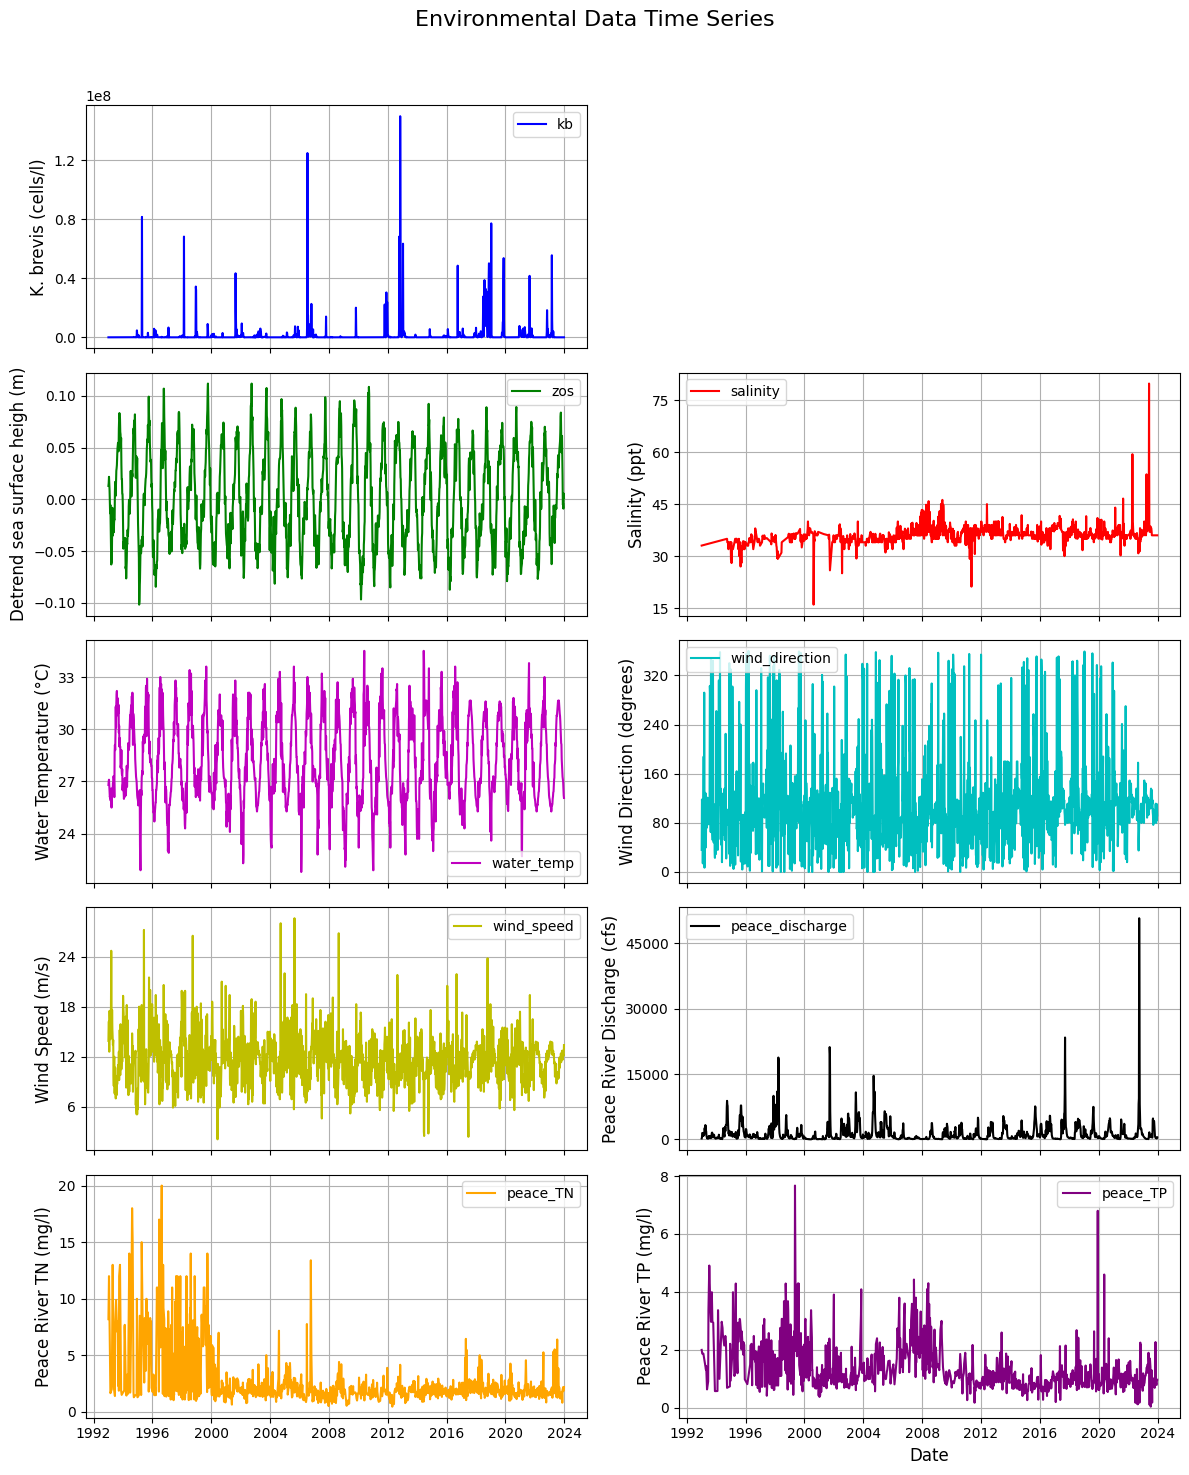

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_interpol is already defined
# df_interpol = pd.DataFrame({...})  # Replace with your actual DataFrame

# Set the index to ensure the time series is on the x-axis
df_interpol.index = pd.to_datetime(df_interpol.index)

# Prepare subplot parameters
variables = [
    {'key': 'kb', 'color': 'b', 'label': 'K. brevis (cells/l)'},
    {'key': 'zos', 'color': 'g', 'label': 'Detrend sea surface heigh (m)'},
    {'key': 'salinity', 'color': 'r', 'label': 'Salinity (ppt)'},
    {'key': 'water_temp', 'color': 'm', 'label': 'Water Temperature (°C)'},
    {'key': 'wind_direction', 'color': 'c', 'label': 'Wind Direction (degrees)'},
    {'key': 'wind_speed', 'color': 'y', 'label': 'Wind Speed (m/s)'},
    {'key': 'peace_discharge', 'color': 'k', 'label': 'Peace River Discharge (cfs)'},
    {'key': 'peace_TN', 'color': 'orange', 'label': 'Peace River TN (mg/l)'},
    {'key': 'peace_TP', 'color': 'purple', 'label': 'Peace River TP (mg/l)'}
]

# Create a figure with subplots for each variable (5x2 layout)
fig, axs = plt.subplots(5, 2, figsize=(12, 15), sharex=True)  # Adjusted figsize for better visibility
axs = axs.flatten()  # Flatten the 2D array of axes for easy iteration

# Function to plot each variable
def plot_variable(ax, key, color, label):
    ax.plot(df_interpol.index, df_interpol[key], color=color, label=key)
    ax.set_ylabel(label, fontsize=12)  # Increased y-label font size
    ax.legend(fontsize=10)              # Increase legend font size
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=10)  # Increase tick label size

    # Limit y-axis ticks for readability
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=5))  # Fewer y-ticks

# Plot Karenia brevis in the first subplot (top position)
plot_variable(axs[0], 'kb', 'b', 'K. brevis (cells/l)')

# Leave the second subplot blank
axs[1].axis('off')  # Hide the second subplot

# Start plotting the driver variables from the third subplot (i.e., (5,2,2))
driver_vars = variables[1:]  # Get all driver variables except 'kb'

# Loop through the driver variables and assign them to the correct subplots
for i, var in enumerate(driver_vars):
    plot_variable(axs[i + 2], var['key'], var['color'], var['label'])  # Start from axs[2]

# Hide any unused subplots (if there are fewer than 10 variables)
for j in range(len(driver_vars) + 2, len(axs)):  # Start from 2 because 0 and 1 are used.
    fig.delaxes(axs[j])

# Set common title and x-axis label
plt.suptitle('Environmental Data Time Series', fontsize=16)  # Main title
plt.xlabel('Date', fontsize=12)  # Increase x-label font size
plt.xticks(rotation=0, fontsize=10)  # Rotate x-axis labels and increase font size

# Save the figure
plt.savefig('figures/data.png', dpi=300, bbox_inches='tight')  # Save with high resolution and tight layout

# Adjust layout and display the plot
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout
plt.show()